# ML Supervised Market Regime Detection

In [1]:
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt

plt.style.use('dark_background')

In [2]:
df = pd.read_parquet('../btc_binance_1d.parquet')
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377
2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264
2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022
2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060


## Ground truth

In [3]:
# ==============================================================================
# MÉTODO 1: Forward Returns (Retornos Futuros a 7 días)
# ==============================================================================
n_days = 21
threshold_fwd = 0.08 # Umbral del 5%

# Calculamos el retorno a 'n' días hacia el futuro
df['Fwd_Return'] = df['Close'].shift(-n_days) / df['Close'] - 1

# Etiquetado
cond_bull_fwd = df['Fwd_Return'] > threshold_fwd
cond_bear_fwd = df['Fwd_Return'] < -threshold_fwd

# 1 = Alcista, -1 = Bajista, 0 = Lateral
df['Regime_Fwd'] = np.select(
    [cond_bull_fwd, cond_bear_fwd], 
    [1, -1], 
    default=0
)

# Nota: Los últimos 'n_days' tendrán NaN porque no conocemos el futuro, los ignoramos para el plot
df.loc[df.index[-n_days:], 'Regime_Fwd'] = np.nan

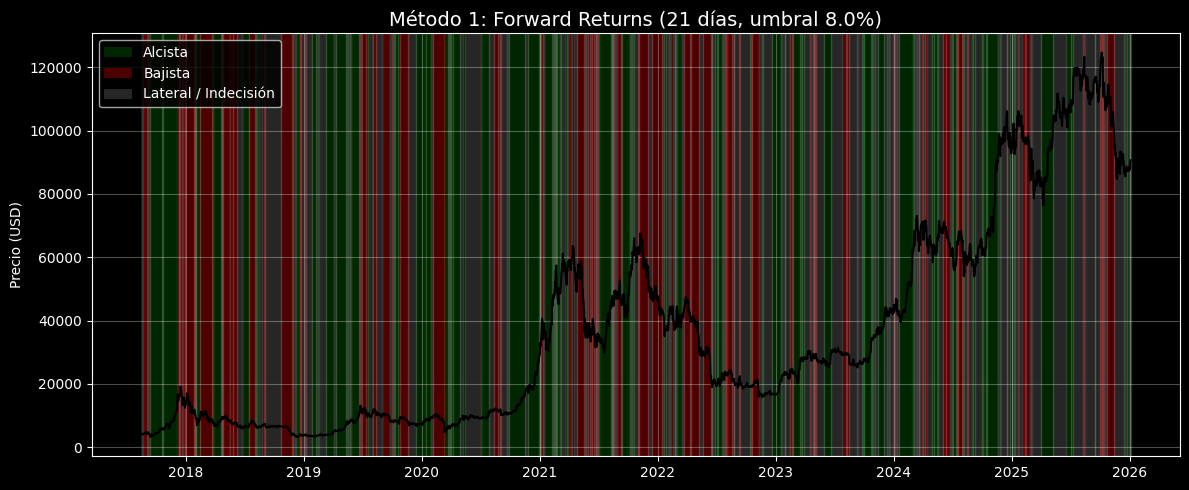

In [41]:
# ==============================================================================
# VISUALIZACIÓN (PLOTTING)
# ==============================================================================
def plot_regimes(ax, df_plot, regime_col, title):
    """Función auxiliar para pintar el gráfico de precio y sombrear los regímenes"""
    ax.plot(df_plot.index, df_plot['Close'], color='black', linewidth=1.5, label='Precio BTC')
    
    ymin, ymax = ax.get_ylim()
    
    # Rellenar el fondo según el régimen
    ax.fill_between(df_plot.index, ymin, ymax, where=(df_plot[regime_col] == 1), 
                    color='green', alpha=0.3, step='mid')
    ax.fill_between(df_plot.index, ymin, ymax, where=(df_plot[regime_col] == -1), 
                    color='red', alpha=0.3, step='mid')
    ax.fill_between(df_plot.index, ymin, ymax, where=(df_plot[regime_col] == 0), 
                    color='gray', alpha=0.3, step='mid')
    
    ax.set_title(title, fontsize=14)
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel('Precio (USD)')
    ax.grid(alpha=0.3)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Limpiar NaNs solo para que el plot no se rompa visualmente
df_plot = df.dropna()

plot_regimes(ax1, df_plot, 'Regime_Fwd', f'Método 1: Forward Returns ({n_days} días, umbral {threshold_fwd*100}%)')

# Leyenda customizada
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.3, label='Alcista'),
                   Patch(facecolor='red', alpha=0.3, label='Bajista'),
                   Patch(facecolor='gray', alpha=0.3, label='Lateral / Indecisión')]
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show();

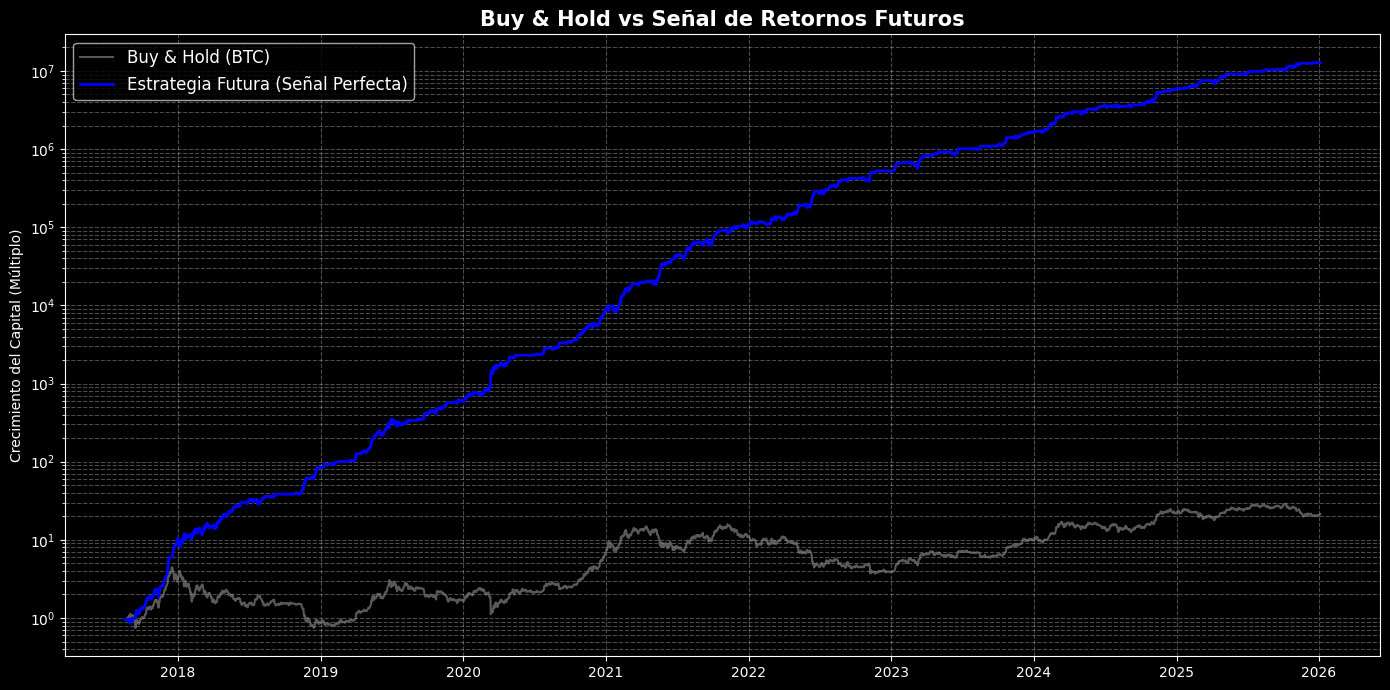

Múltiplo final Buy & Hold: 21.36x
Múltiplo final Estrategia Perfecta: 12796057.27x


In [44]:
# 1. Calcular el retorno diario del precio (Buy & Hold)
df['Daily_Return'] = df['Close'].pct_change()

# 2. Calcular el retorno de la Estrategia Ideal
# IMPORTANTE: Desplazamos la señal 1 periodo (.shift(1)) porque la 
# señal que calculamos al CIERRE de hoy, se ejecuta en la apertura de mañana.
# Si la señal es 1 (Alcista) -> Compramos (Largo)
# Si la señal es -1 (Bajista) -> Vendemos (Corto, ganamos si baja)
# Si la señal es 0 (Lateral) -> Nos quedamos en Cash (Retorno 0)
df['Strat_Return'] = df['Regime_Fwd'].shift(1) * df['Daily_Return']

# 3. Calcular retornos acumulados (Multiplicador de capital)
# Borramos los NaNs iniciales/finales para poder calcular el producto acumulado
df_sim = df.dropna(subset=['Daily_Return', 'Strat_Return']).copy()

df_sim['Cum_BnH'] = (1 + df_sim['Daily_Return']).cumprod()
df_sim['Cum_Strat'] = (1 + df_sim['Strat_Return']).cumprod()

# 4. Visualización
fig, ax = plt.subplots(figsize=(14, 7))

# Curva de Buy & Hold
ax.plot(df_sim.index, df_sim['Cum_BnH'], label='Buy & Hold (BTC)', color='gray', alpha=0.7)

# Curva de la Estrategia con "Bola de Cristal"
ax.plot(df_sim.index, df_sim['Cum_Strat'], label='Estrategia Futura (Señal Perfecta)', color='blue', linewidth=2)

ax.set_title('Buy & Hold vs Señal de Retornos Futuros', fontsize=15, fontweight='bold')
ax.set_ylabel('Crecimiento del Capital (Múltiplo)')
ax.set_yscale('log') # Escala Logarítmica fundamental para ver bien los rendimientos
ax.grid(True, alpha=0.3, which='both', linestyle='--')
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

# Extra: Mostrar métricas finales por consola
final_bnh = df_sim['Cum_BnH'].iloc[-1]
final_strat = df_sim['Cum_Strat'].iloc[-1]
print(f"Múltiplo final Buy & Hold: {final_bnh:.2f}x")
print(f"Múltiplo final Estrategia Perfecta: {final_strat:.2f}x")

## Features

In [4]:
df_features = pd.DataFrame(index=df.index)

# Guardamos nuestro Target (y)
df_features['Target_Regime'] = df['Regime_Fwd']

# ==============================================================================
# 1. TENDENCIA (Trend)
# ==============================================================================
# ADX y Direccionalidad
adx = ta.trend.ADXIndicator(high=df['High'], low=df['Low'], close=df['Close'], window=14)
df_features['ADX_14'] = adx.adx()
df_features['DI_Plus_14'] = adx.adx_pos()
df_features['DI_Minus_14'] = adx.adx_neg()
df_features['DI_Diff'] = df_features['DI_Plus_14'] - df_features['DI_Minus_14']

# Medias Móviles Exponenciales (EMAs)
df_features['EMA_9'] = ta.trend.ema_indicator(close=df['Close'], window=9)
df_features['EMA_20'] = ta.trend.ema_indicator(close=df['Close'], window=20)
df_features['EMA_50'] = ta.trend.ema_indicator(close=df['Close'], window=50)
df_features['EMA_200'] = ta.trend.ema_indicator(close=df['Close'], window=200)

# "Ángulos" (Momentum de las EMAs a 3 días)
df_features['EMA_9_Slope'] = df_features['EMA_9'].pct_change(periods=3)
df_features['EMA_20_Slope'] = df_features['EMA_20'].pct_change(periods=3)
df_features['EMA_50_Slope'] = df_features['EMA_50'].pct_change(periods=3)

# MACD
macd = ta.trend.MACD(close=df['Close'])
df_features['MACD_Line'] = macd.macd()
df_features['MACD_Signal'] = macd.macd_signal()
df_features['MACD_Hist'] = macd.macd_diff()

# ==============================================================================
# 2. MOMENTUM (Momentum)
# ==============================================================================
# RSI en múltiples ventanas temporales
df_features['RSI_14'] = ta.momentum.rsi(close=df['Close'], window=14)
df_features['RSI_21'] = ta.momentum.rsi(close=df['Close'], window=21)

# Oscilador Estocástico
stoch = ta.momentum.StochasticOscillator(high=df['High'], low=df['Low'], close=df['Close'])
df_features['Stoch_K'] = stoch.stoch()
df_features['Stoch_D'] = stoch.stoch_signal()

# Tasa de Cambio (ROC) del precio
df_features['ROC_10'] = ta.momentum.roc(close=df['Close'], window=10)

# ==============================================================================
# 3. VOLATILIDAD (Volatility)
# ==============================================================================
# ATR Normalizado (NATR)
df_features['ATR_14'] = ta.volatility.average_true_range(high=df['High'], low=df['Low'], close=df['Close'], window=14)
df_features['NATR_14'] = df_features['ATR_14'] / df['Close']

# Bandas de Bollinger
bollinger = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df_features['BB_Width'] = bollinger.bollinger_wband() # Ancho de las bandas
df_features['BB_Pband'] = bollinger.bollinger_pband() # Posición del precio respecto a las bandas (%B)

# ==============================================================================
# 4. VOLUMEN (Volume)
# ==============================================================================
# OBV y su pendiente
df_features['OBV'] = ta.volume.on_balance_volume(close=df['Close'], volume=df['Volume'])
df_features['OBV_Slope'] = df_features['OBV'].pct_change(periods=5)

# Chaikin Money Flow (CMF) - Excelente para ver presión institucional
df_features['CMF_20'] = ta.volume.chaikin_money_flow(high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume'], window=20)

# ==============================================================================
# LIMPIEZA DE DATOS (Drop NaNs e Infinitos)
# ==============================================================================
# Reemplazar infinitos por NaN y luego botar todas las filas con NaN
# (Se perderán los primeros ~200 días por la EMA_200 y los últimos días por tu Target)
df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
df_features.dropna(inplace=True)

print(f"Dataset de Features listo. Dimensiones: {df_features.shape}")
df_features.columns

Dataset de Features listo. Dimensiones: (2863, 27)


Index(['Target_Regime', 'ADX_14', 'DI_Plus_14', 'DI_Minus_14', 'DI_Diff',
       'EMA_9', 'EMA_20', 'EMA_50', 'EMA_200', 'EMA_9_Slope', 'EMA_20_Slope',
       'EMA_50_Slope', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'RSI_14',
       'RSI_21', 'Stoch_K', 'Stoch_D', 'ROC_10', 'ATR_14', 'NATR_14',
       'BB_Width', 'BB_Pband', 'OBV', 'OBV_Slope', 'CMF_20'],
      dtype='object')

In [ ]:
from ydata_profiling import ProfileReport

# 1. Definir las columnas absolutas (no estacionarias) que ensucian el EDA
cols_to_drop = [
    'EMA_9', 'EMA_20', 'EMA_50', 'EMA_200',  # Precios absolutos
    'MACD_Line', 'MACD_Signal',              # Escalan según el precio de BTC
    'ATR_14',                                # Volatilidad absoluta (ya tenemos el NATR_14)
    'OBV'                                    # Volumen acumulado absoluto (ya tenemos el OBV_Slope)
]

# 2. Filtrar el DataFrame dejando solo las variables estacionarias y el Target
df_eda = df_features.drop(columns=cols_to_drop)

# 3. Generar el reporte interactivo
print(f"Generando reporte con {df_eda.shape[1]} columnas. Esto puede tardar un minuto...")

# Usamos explorative=True para que haga un análisis más profundo de distribuciones
profile = ProfileReport(df_eda, title="EDA - Bitcoin Market Regimes", explorative=True)
profile.to_file("report.html")

print("¡Listo! Abre el archivo 'report.html' en tu navegador.")

Generando reporte con 19 columnas. Esto puede tardar un minuto...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 38.19it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

¡Listo! Abre el archivo 'report.html' en tu navegador.


In [ ]:
cols_to_drop = [
    'EMA_9', 'EMA_20', 'EMA_50', 'EMA_200',  # Precios absolutos
    'MACD_Line', 'MACD_Signal',              # Escalan según el precio de BTC
    'ATR_14',                                # Volatilidad absoluta (ya tenemos el NATR_14)
    'OBV'                                    # Volumen acumulado absoluto (ya tenemos el OBV_Slope)
]

# 2. Filtrar el DataFrame dejando solo las variables estacionarias y el Target
df_eda = df_features.drop(columns=cols_to_drop)

final_features = [
    'RSI_21', 'Stoch_K', 'MACD_Hist',          # Momentum
    'EMA_20_Slope', 'EMA_50_Slope', 'DI_Diff', # Tendencia
    'NATR_14', 'BB_Width',                     # Volatilidad
    'CMF_20', 'OBV_Slope',                     # Volumen
    'Target_Regime'
]

df_features = df_eda[final_features]

In [8]:
df_features.head()

,RSI_21,Stoch_K,MACD_Hist,EMA_20_Slope,EMA_50_Slope,DI_Diff,NATR_14,BB_Width,CMF_20,OBV_Slope,Target_Regime
Date,,,,,,,,,,,
2018-03-04,54.938920,89.207991,200.248023,0.031429,0.008459,6.414775,0.079016,28.381160,0.057258,-0.956627,-1.0
2018-03-05,54.602038,86.778883,191.911804,0.032064,0.009652,7.454727,0.075603,24.261664,0.061230,-0.803475,-1.0
2018-03-06,50.658521,59.201708,128.321879,0.021782,0.006478,-0.167161,0.081030,22.241874,-0.010827,-0.274081,-1.0
2018-03-07,46.779356,26.084100,28.740152,0.004863,0.000291,-9.259386,0.092246,22.435115,-0.066718,1.378222,-1.0
2018-03-08,43.980338,7.986415,-77.516779,-0.015356,-0.007737,-11.063172,0.099559,24.833168,-0.122732,5.994862,-1.0


## Training Model

In [15]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [10]:
# 1. Tu división temporal exacta (70% Train / 30% Test)
split_index = int(len(df_features) * 0.70)

# Separamos X e y manteniendo el orden cronológico estricto
X = df_features.drop(columns=['Target_Regime'])
y = df_features['Target_Regime']

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data: {len(X_train)} candles ({X_train.index[0].date()} - {X_train.index[-1].date()})")
print(f"Test data: {len(X_test)} candles ({X_test.index[0].date()} - {X_test.index[-1].date()})")

Training data: 2004 candles (2018-03-04 - 2023-08-28)
Test data: 859 candles (2023-08-29 - 2026-01-03)


In [29]:
def plot_learning_curve(estimator, X, y, metric='accuracy', cv=10, ylim=(0.0, 1.1), estimator_name=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv,
        scoring=metric,
        n_jobs=-1 
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    title = f"{estimator_name} Learning Curve - Metric: {metric}"
    plt.title(title)
    
    plt.xlabel("Training examples")
    plt.ylabel(metric)
    plt.ylim(ylim)

    plt.plot(train_sizes, train_mean, 'o-', color="b", label=f"Training {metric}")
    plt.fill_between(train_sizes, 
                     train_mean - train_std, 
                     train_mean + train_std, 
                     alpha=0.1, color="b")

    plt.plot(train_sizes, test_mean, 's--', color="g", label=f"Cross-validation {metric}")
    plt.fill_between(train_sizes, 
                     test_mean - test_std, 
                     test_mean + test_std, 
                     alpha=0.1, color="g")

    plt.grid(True)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def validation(estimator, X, y, estimator_name):
    y_val_pred = estimator.predict(X)

    acc = (y_val_pred == y).mean()

    print(f"Validation Accuracy: {acc:.3f}")
    
    print("\nClassification Report (Validation Set):\n")
    print(classification_report(y, y_val_pred))

    # 4. Matriu de confusió
    ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=y_val_pred, cmap="Blues")
    title = f"Confusion Matrix - {estimator_name} (Validation Set)"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_model_returns(model, X_test, df_original):
    """
    Simula y grafica los retornos de las estrategias Long-Short y Long-Only 
    del modelo frente al Buy & Hold.
    """
    # 1. Generar predicciones del modelo
    y_pred = model.predict(X_test)
    
    # 2. Crear DataFrame de simulación alineado
    df_sim = pd.DataFrame(index=X_test.index)
    df_sim['Prediction'] = y_pred
    
    # 3. Traer el retorno diario real del activo
    if 'Daily_Return' not in df_original.columns:
        df_original['Daily_Return'] = df_original['Close'].pct_change()
    df_sim['Daily_Return'] = df_original.loc[X_test.index, 'Daily_Return']
    
    # =========================================================================
    # 4. DEFINIR REGLAS DE POSICIÓN (Con Shift de 1 día)
    # =========================================================================
    # Estrategia Long-Short: Toma los valores tal cual (1, 0, -1)
    df_sim['Pos_LS'] = df_sim['Prediction'].shift(1)
    
    # Estrategia Long-Only: Si predice 1, compra. Si predice 0 o -1, cash (0).
    # Usamos np.where y lo convertimos a Serie para mantener el índice de fechas
    pos_lo_array = np.where(df_sim['Prediction'] == 1, 1, 0)
    df_sim['Pos_LO'] = pd.Series(pos_lo_array, index=df_sim.index).shift(1)
    
    # Limpiamos el primer día (NaN) generado por el shift
    df_sim = df_sim.dropna()
    
    # 5. Calcular los retornos diarios de cada variante
    df_sim['Ret_LS'] = df_sim['Pos_LS'] * df_sim['Daily_Return']
    df_sim['Ret_LO'] = df_sim['Pos_LO'] * df_sim['Daily_Return']
    
    # 6. Calcular el multiplicador de capital (Retorno Acumulado)
    df_sim['Cum_BnH'] = (1 + df_sim['Daily_Return']).cumprod()
    df_sim['Cum_LS'] = (1 + df_sim['Ret_LS']).cumprod()
    df_sim['Cum_LO'] = (1 + df_sim['Ret_LO']).cumprod()
    
    # =========================================================================
    # VISUALIZACIÓN
    # =========================================================================
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Curvas de capital
    ax.plot(df_sim.index, df_sim['Cum_BnH'], label='Buy & Hold (Activo)', color='gray', alpha=0.5, linestyle='--')
    ax.plot(df_sim.index, df_sim['Cum_LS'], label='Estrategia: Long-Short', color='purple', linewidth=2)
    ax.plot(df_sim.index, df_sim['Cum_LO'], label='Estrategia: Long-Only', color='teal', linewidth=2)
    
    # Sombreado para visualizar dónde el modelo está activando cortos (-1)
    ymin, ymax = ax.get_ylim()
    ax.fill_between(df_sim.index, ymin, ymax, where=(df_sim['Pos_LS'] == -1), 
                    color='red', alpha=0.08, label='Zonas de Predicción Bajista (-1)')
    
    ax.fill_between(df_sim.index, ymin, ymax, where=(df_sim['Pos_LS'] == 1), 
                    color='green', alpha=0.08, label='Zonas de Predicción Alcista (1)')
    
    ax.set_title('Rendimiento: Long-Short vs Long-Only vs Buy & Hold (Datos Test)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Crecimiento del Capital (Múltiplo)')
    ax.set_yscale('log') # Fundamental para series financieras
    ax.grid(True, alpha=0.3, which='both', linestyle='--')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # MÉTRICAS FINALES
    # =========================================================================
    print("\n=== RESULTADOS DE LA SIMULACIÓN EN TEST ===")
    print(f"Múltiplo final Buy & Hold:  {df_sim['Cum_BnH'].iloc[-1]:.2f}x")
    print(f"Múltiplo final Long-Only:   {df_sim['Cum_LO'].iloc[-1]:.2f}x")
    print(f"Múltiplo final Long-Short:  {df_sim['Cum_LS'].iloc[-1]:.2f}x")
    print("===========================================")


Iniciando optimización de hiperparámetros (GridSearchCV)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV f1_macro: 0.348
Best params: {'svc__C': 10, 'svc__gamma': 0.001}
Validation Accuracy: 0.341

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.19      0.67      0.29       105
         0.0       0.72      0.24      0.36       497
         1.0       0.32      0.40      0.35       257

    accuracy                           0.34       859
   macro avg       0.41      0.44      0.34       859
weighted avg       0.54      0.34      0.35       859



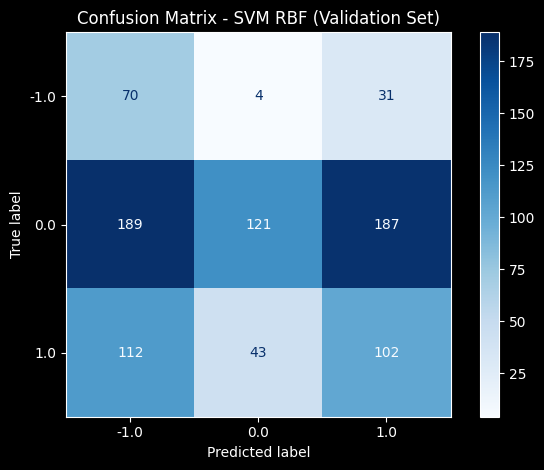

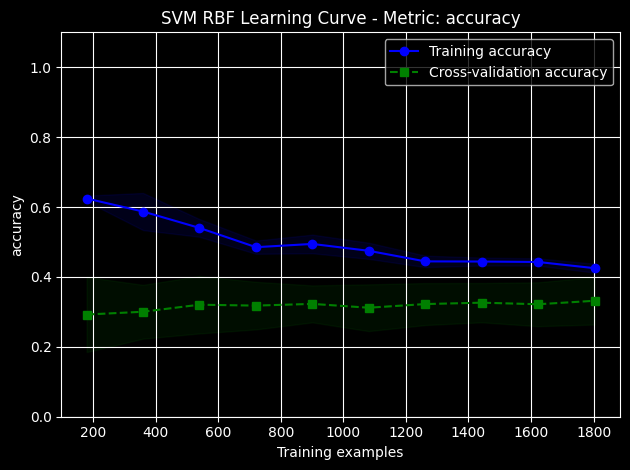

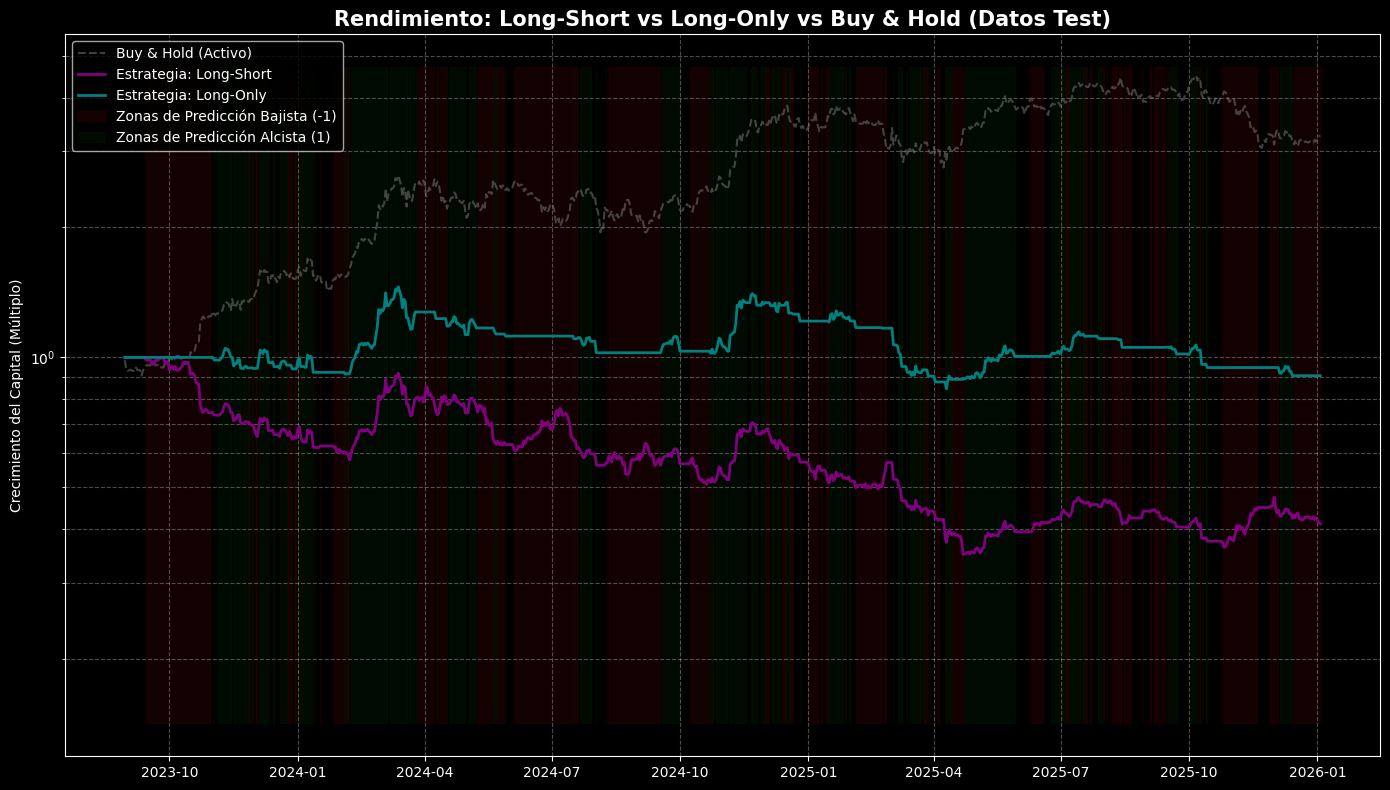


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   0.91x
Múltiplo final Long-Short:  0.41x


In [30]:
from sklearn.svm import SVC

METRIC = 'accuracy'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X.columns)
    ])

svc_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    ("svc", SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

param_grid = {
    "svc__C": [0.01, 0.1, 1, 10, 100],
    "svc__gamma": ['scale', 'auto', 0.001, 0.01, 0.1],
}

cv_strategy = TimeSeriesSplit(n_splits=5)

# 5. Búsqueda Grid
svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (GridSearchCV)...")
svc_grid.fit(X_train, y_train)

print(f"\nBest CV f1_macro: {svc_grid.best_score_:.3f}")
print(f"Best params: {svc_grid.best_params_}")

# 6. Extracción del mejor modelo
best_svm_rbf = svc_grid.best_estimator_

# (Tus funciones personalizadas de evaluación irían aquí)
validation(estimator=best_svm_rbf, X=X_test, y=y_test, estimator_name='SVM RBF')
plot_learning_curve(estimator=best_svm_rbf, X=X_train, y=y_train, metric=METRIC, estimator_name='SVM RBF')
plot_model_returns(best_svm_rbf, X_test, df)



Iniciando optimización de hiperparámetros (Random Forest)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best CV f1_macro: 0.347
Best params: {'rf__max_depth': 15, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 50}
Validation Accuracy: 0.363

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.09      0.21      0.13       105
         0.0       0.55      0.47      0.51       497
         1.0       0.28      0.21      0.24       257

    accuracy                           0.36       859
   macro avg       0.31      0.30      0.29       859
weighted avg       0.41      0.36      0.38       859



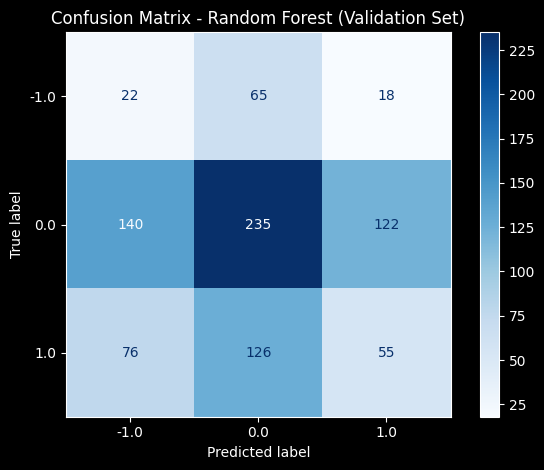

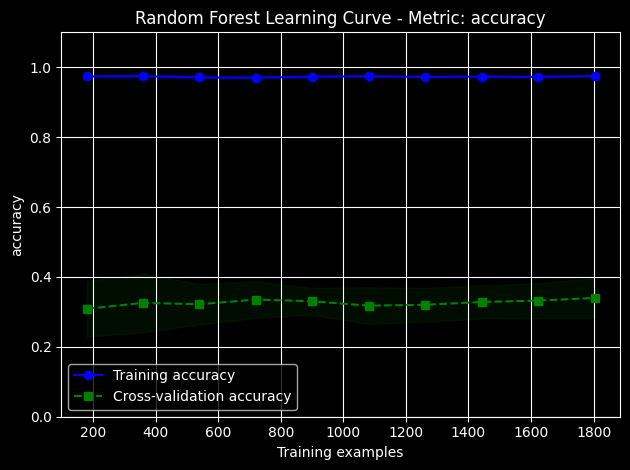

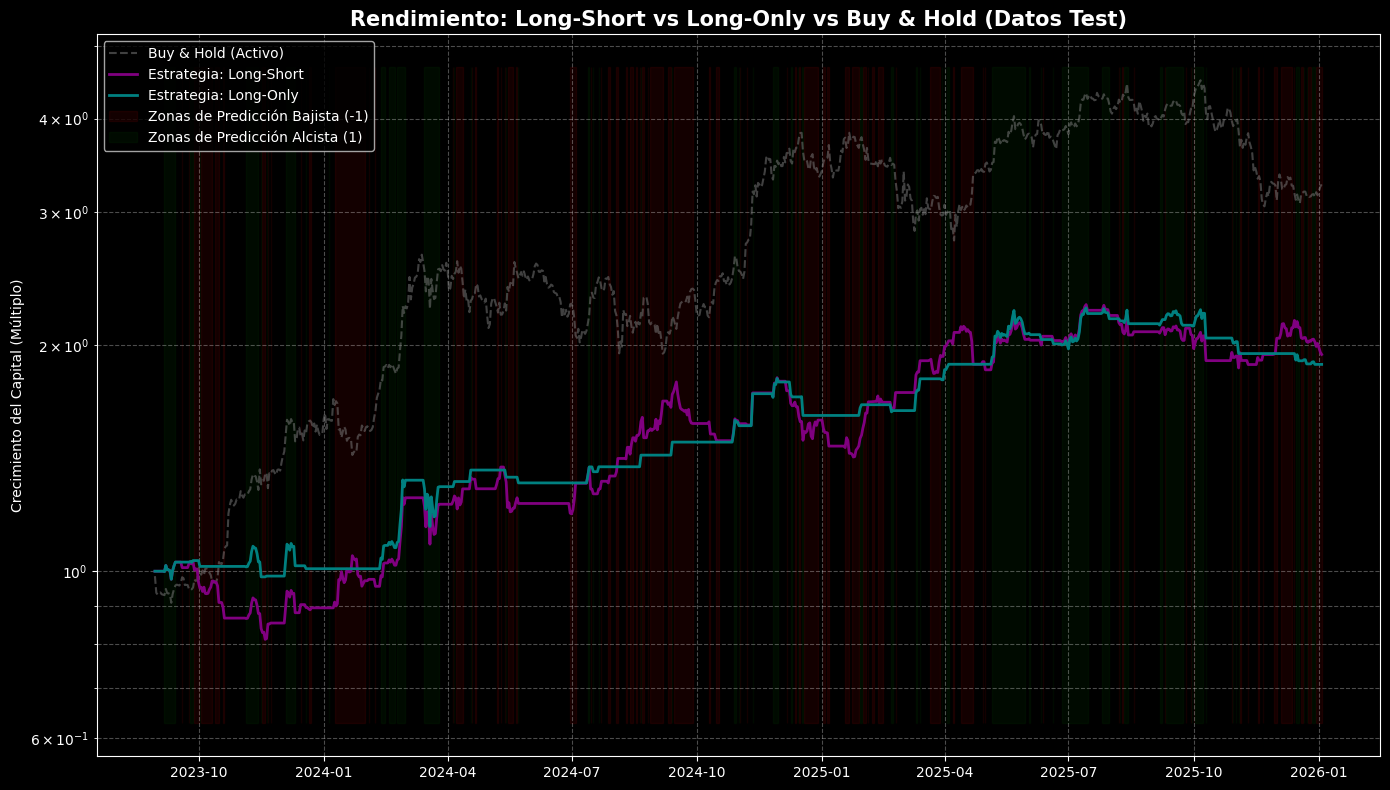


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.88x
Múltiplo final Long-Short:  1.94x


In [31]:
from sklearn.ensemble import RandomForestClassifier

METRIC = 'accuracy'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    ("rf", RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],       # Número de "árboles" en el bosque
    "rf__max_depth": [None, 5, 10, 15],       # Profundidad máxima (vital para evitar sobreajuste)
    "rf__min_samples_split": [2, 5, 10],      # Muestras mínimas para ramificar un nodo
    "rf__min_samples_leaf": [1, 2, 4]         # Muestras mínimas para formar una decisión final
}


cv_strategy = TimeSeriesSplit(n_splits=5)


rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Random Forest)...")
rf_grid.fit(X_train, y_train)

print(f"\nBest CV f1_macro: {rf_grid.best_score_:.3f}")
print(f"Best params: {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_

validation(estimator=best_rf, X=X_test, y=y_test, estimator_name='Random Forest')
plot_learning_curve(estimator=best_rf, X=X_train, y=y_train, metric=METRIC, estimator_name='Random Forest')
plot_model_returns(best_rf, X_test, df)


Iniciando optimización de hiperparámetros (Random Forest)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best CV f1_macro: 0.326
Best params: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Validation Accuracy: 0.385

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.11      0.22      0.15       105
         0.0       0.54      0.54      0.54       497
         1.0       0.26      0.16      0.20       257

    accuracy                           0.39       859
   macro avg       0.30      0.31      0.30       859
weighted avg       0.40      0.39      0.39       859



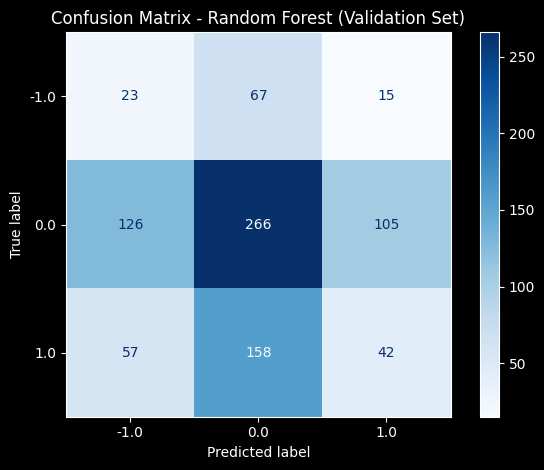

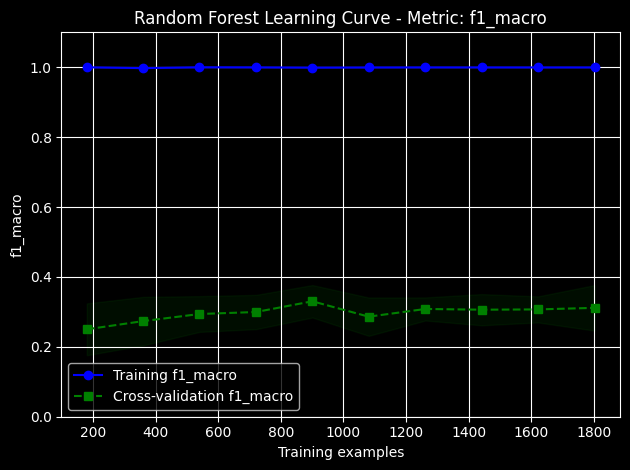

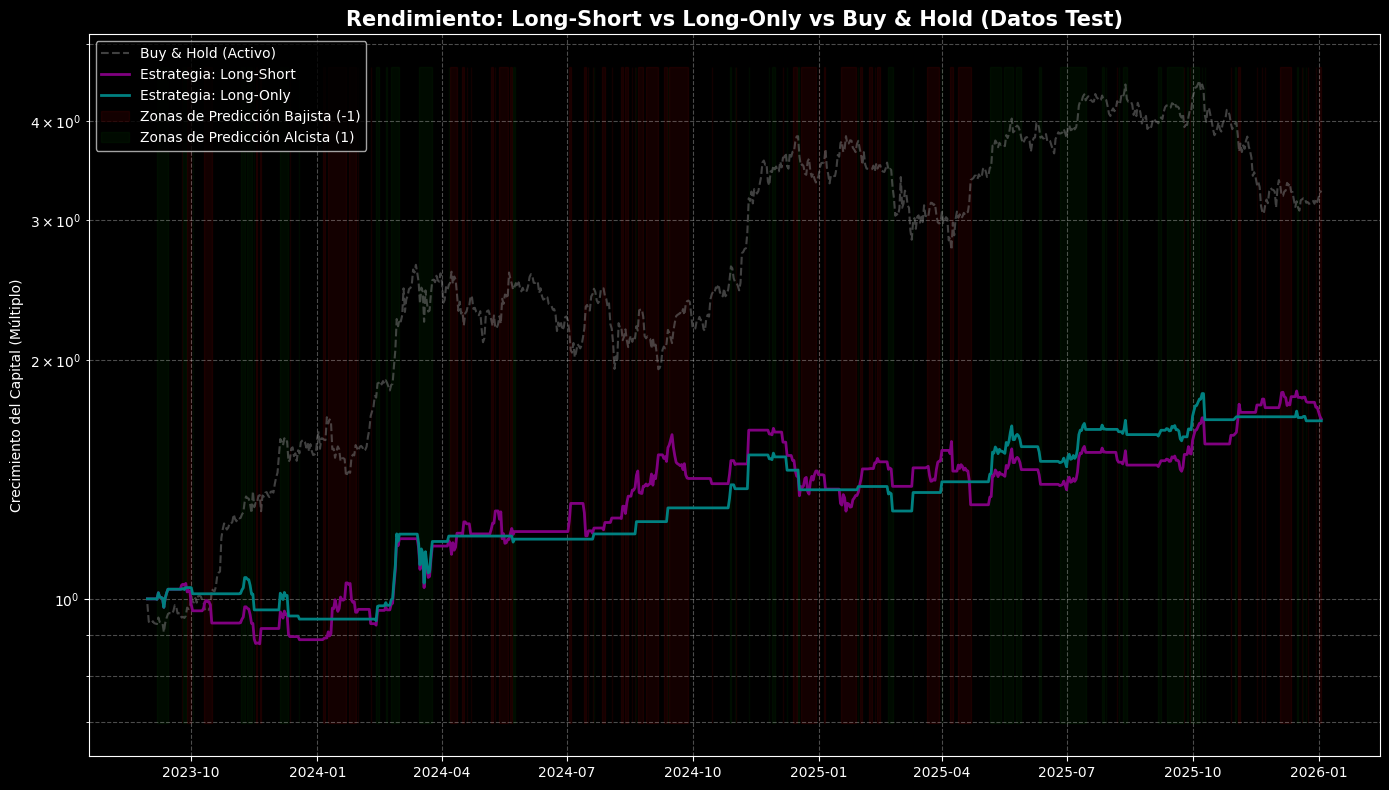


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.68x
Múltiplo final Long-Short:  1.69x


In [32]:
from sklearn.ensemble import RandomForestClassifier

METRIC = 'f1_macro'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    ("rf", RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],       # Número de "árboles" en el bosque
    "rf__max_depth": [None, 5, 10, 15],       # Profundidad máxima (vital para evitar sobreajuste)
    "rf__min_samples_split": [2, 5, 10],      # Muestras mínimas para ramificar un nodo
    "rf__min_samples_leaf": [1, 2, 4]         # Muestras mínimas para formar una decisión final
}


cv_strategy = TimeSeriesSplit(n_splits=5)


rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Random Forest)...")
rf_grid.fit(X_train, y_train)

print(f"\nBest CV f1_macro: {rf_grid.best_score_:.3f}")
print(f"Best params: {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_

validation(estimator=best_rf, X=X_test, y=y_test, estimator_name='Random Forest')
plot_learning_curve(estimator=best_rf, X=X_train, y=y_train, metric=METRIC, estimator_name='Random Forest')
plot_model_returns(best_rf, X_test, df)


Iniciando optimización de hiperparámetros (XGBoost)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV accuracy: 0.371
Best params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Validation Accuracy: 0.400

Classification Report (Validation Set):

              precision    recall  f1-score   support

         0.0       0.10      0.20      0.13       105
         1.0       0.56      0.56      0.56       497
         2.0       0.30      0.18      0.23       257

    accuracy                           0.40       859
   macro avg       0.32      0.31      0.31       859
weighted avg       0.43      0.40      0.41       859



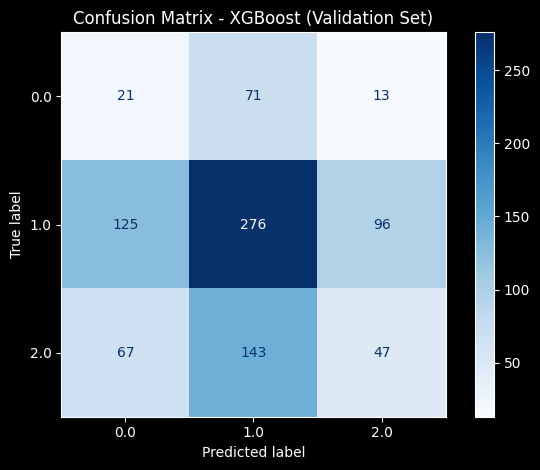

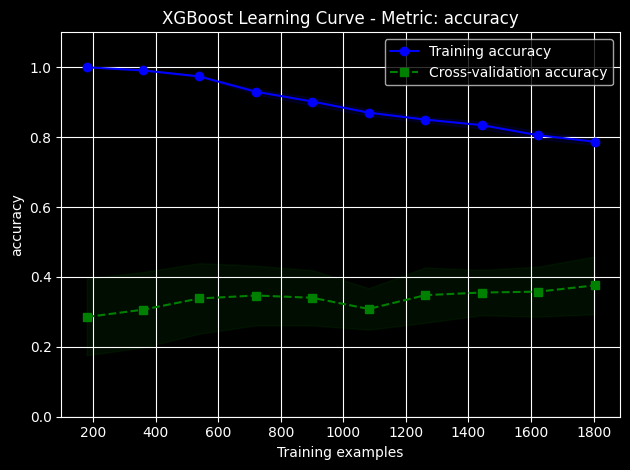

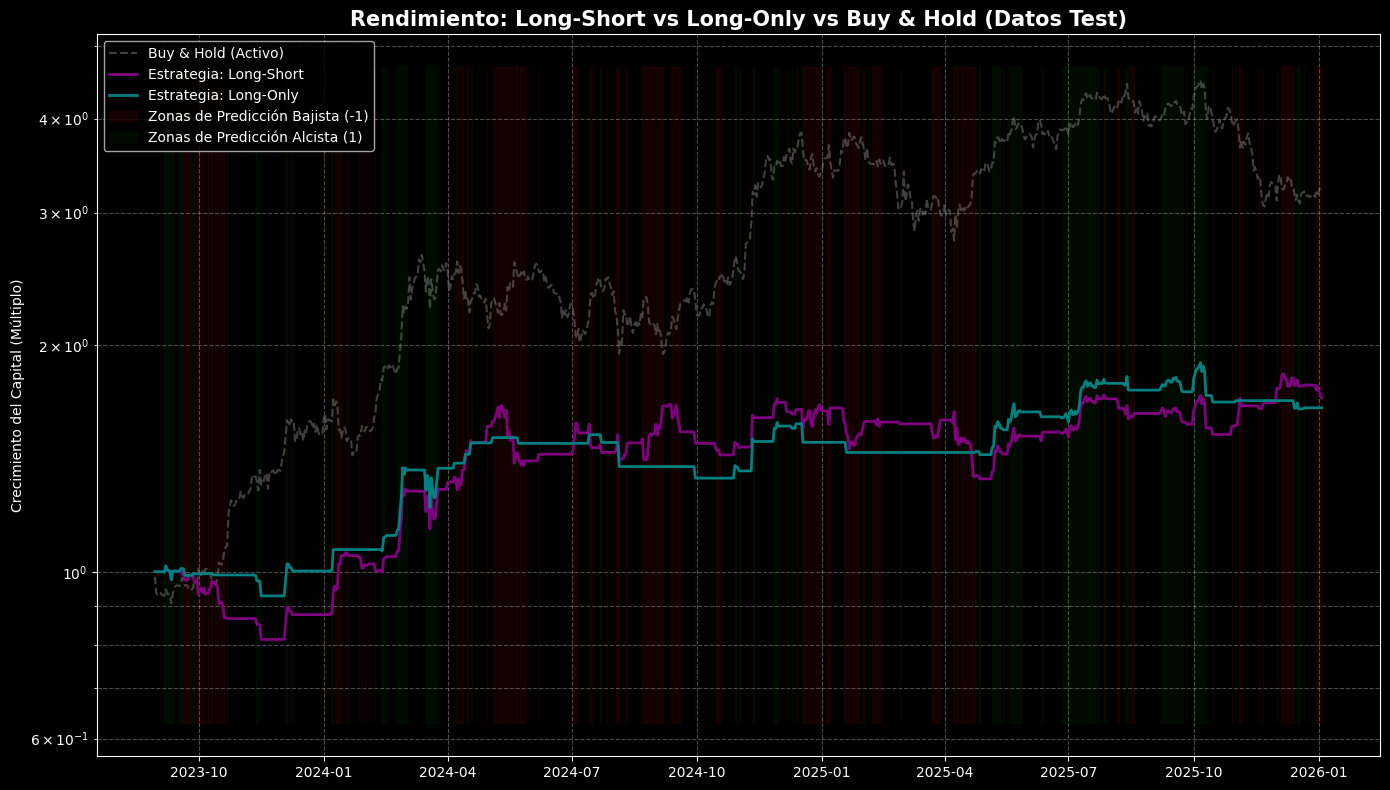


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.65x
Múltiplo final Long-Short:  1.70x


In [35]:
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone

METRIC = 'accuracy'

y_train_xgb = y_train + 1
y_test_xgb = y_test + 1

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    ("xgb", XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

y_train_xgb = y_train + 1

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (XGBoost)...")
xgb_grid.fit(X_train, y_train_xgb)

print(f"\nBest CV {METRIC}: {xgb_grid.best_score_:.3f}")
print(f"Best params: {xgb_grid.best_params_}")

best_xgb = xgb_grid.best_estimator_

validation(estimator=best_xgb, X=X_test, y=y_test_xgb, estimator_name='XGBoost')
plot_learning_curve(estimator=best_xgb, X=X_train, y=y_train_xgb, metric=METRIC, estimator_name='XGBoost')


class FinWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return self.model.predict(X) - 1

plot_model_returns(FinWrapper(best_xgb), X_test, df) 


Iniciando optimización de hiperparámetros (XGBoost)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV f1_macro: 0.352
Best params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
Validation Accuracy: 0.375

Classification Report (Validation Set):

              precision    recall  f1-score   support

         0.0       0.12      0.28      0.17       105
         1.0       0.54      0.52      0.53       497
         2.0       0.25      0.14      0.18       257

    accuracy                           0.37       859
   macro avg       0.30      0.31      0.29       859
weighted avg       0.40      0.37      0.38       859



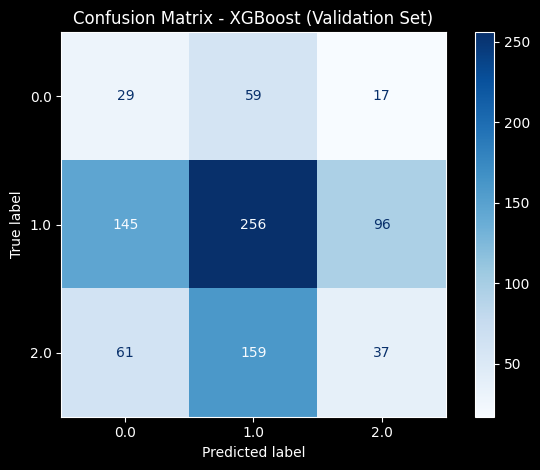

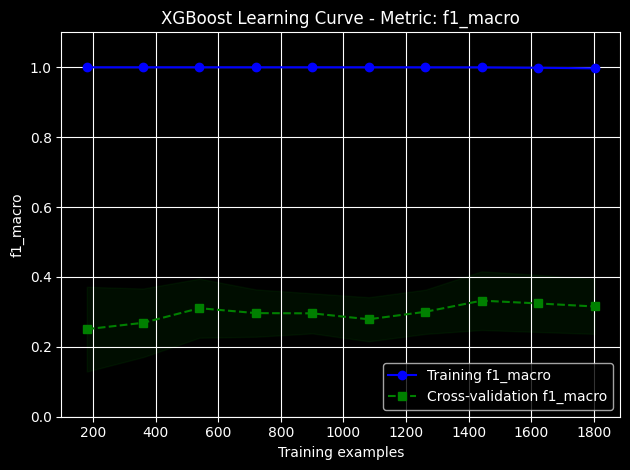

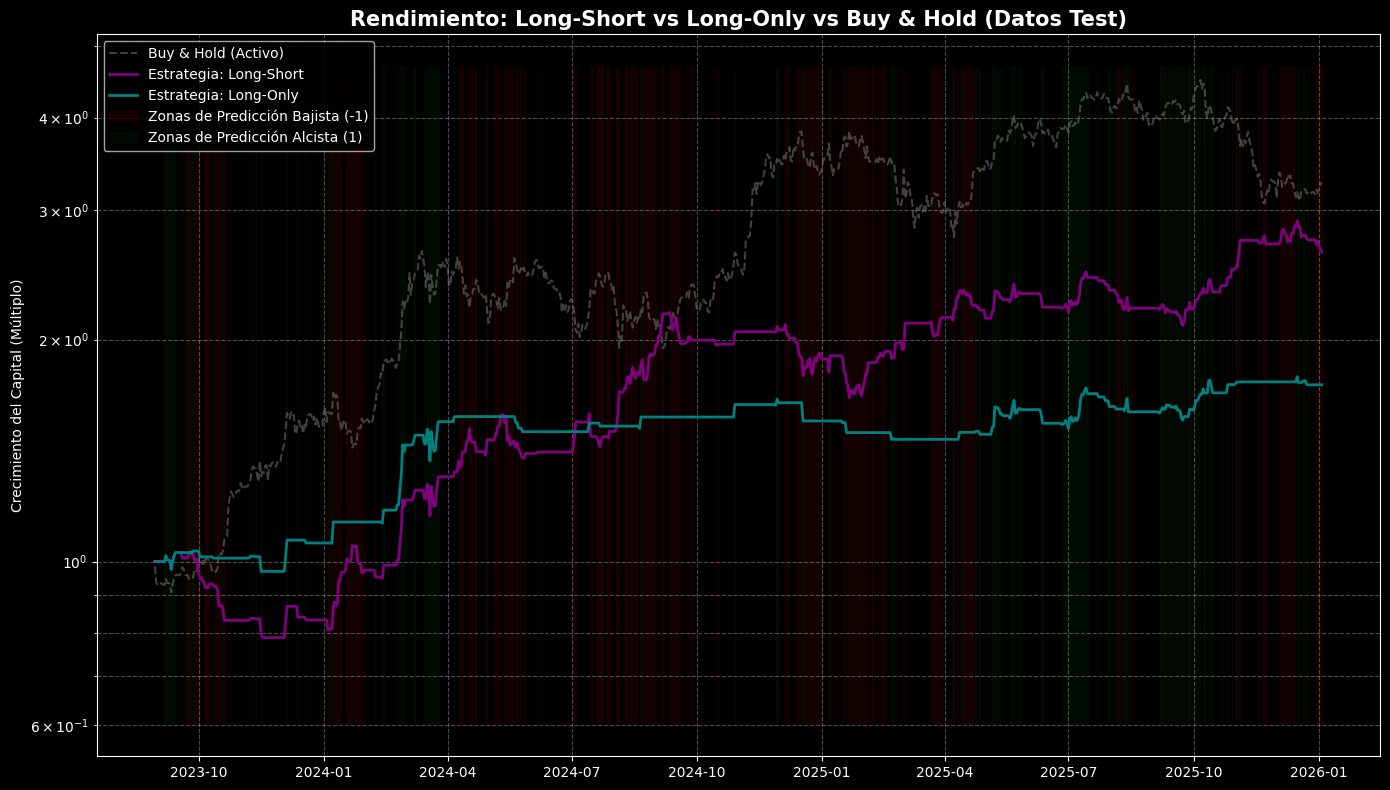


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.74x
Múltiplo final Long-Short:  2.63x


In [36]:
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone

METRIC = 'f1_macro'

y_train_xgb = y_train + 1
y_test_xgb = y_test + 1

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    ("xgb", XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

y_train_xgb = y_train + 1

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (XGBoost)...")
xgb_grid.fit(X_train, y_train_xgb)

print(f"\nBest CV {METRIC}: {xgb_grid.best_score_:.3f}")
print(f"Best params: {xgb_grid.best_params_}")

best_xgb = xgb_grid.best_estimator_

validation(estimator=best_xgb, X=X_test, y=y_test_xgb, estimator_name='XGBoost')
plot_learning_curve(estimator=best_xgb, X=X_train, y=y_train_xgb, metric=METRIC, estimator_name='XGBoost')


class FinWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return self.model.predict(X) - 1

plot_model_returns(FinWrapper(best_xgb), X_test, df) 


Iniciando optimización de hiperparámetros (Red Neuronal MLP)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best CV accuracy: 0.386
Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (20,), 'mlp__learning_rate_init': 0.01}
Validation Accuracy: 0.484

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.16      0.31      0.21       105
         0.0       0.61      0.69      0.65       497
         1.0       0.46      0.16      0.24       257

    accuracy                           0.48       859
   macro avg       0.41      0.39      0.37       859
weighted avg       0.51      0.48      0.47       859



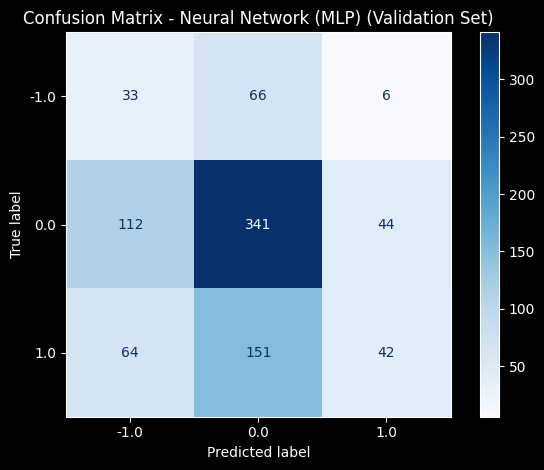

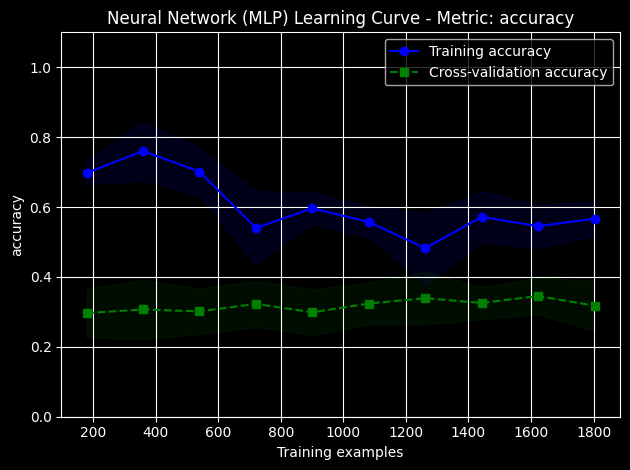

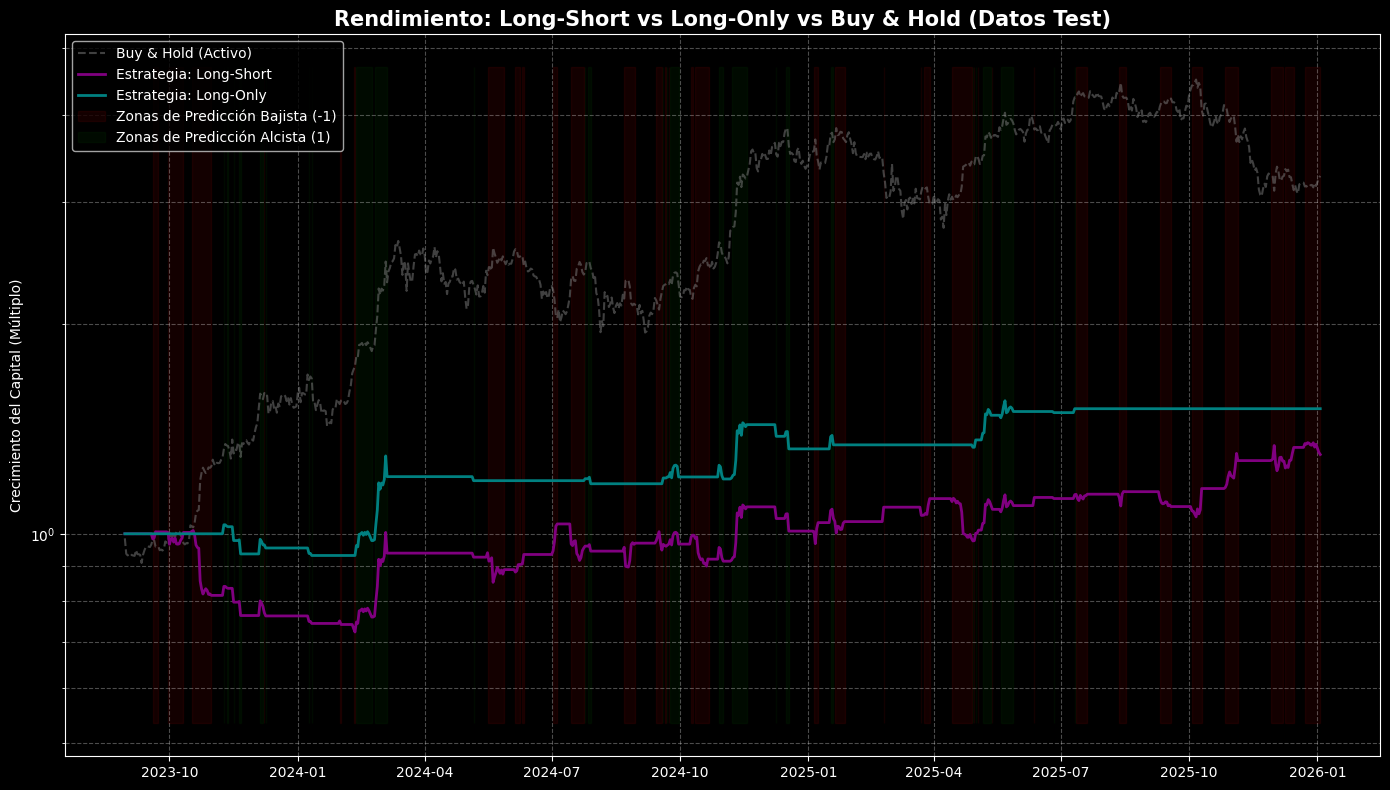


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.51x
Múltiplo final Long-Short:  1.30x


In [37]:
from sklearn.neural_network import MLPClassifier

METRIC = 'accuracy'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

mlp_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    # max_iter alto para asegurar que la red converja (no se detenga antes de aprender)
    ("mlp", MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

# Grid de Hiperparámetros para la Red Neuronal
param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(10,), (20,), (10, 20, 10)], 
    # Función de activación (tanh suele ir muy bien en finanzas)
    "mlp__activation": ['relu', 'tanh'],
    # Regularización L2 (vital para evitar sobreajuste en datos ruidosos)
    "mlp__alpha": [0.0001, 0.01, 0.1],
    # Tasa de aprendizaje
    "mlp__learning_rate_init": [0.001, 0.01]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Red Neuronal MLP)...")
# Usamos y_train normal (-1, 0, 1), MLP lo soporta sin problemas
mlp_grid.fit(X_train, y_train)

print(f"\nBest CV {METRIC}: {mlp_grid.best_score_:.3f}")
print(f"Best params: {mlp_grid.best_params_}")

best_mlp = mlp_grid.best_estimator_

# Evaluación y gráficas usando y_test original
validation(estimator=best_mlp, X=X_test, y=y_test, estimator_name='Neural Network (MLP)')
plot_learning_curve(estimator=best_mlp, X=X_train, y=y_train, metric=METRIC, estimator_name='Neural Network (MLP)')

# Simulación financiera directa (sin wrappers, el MLP escupe -1, 0, 1)
plot_model_returns(best_mlp, X_test, df)
# plot_model_returns_variants(best_mlp, X_test, df) # Opcional


Iniciando optimización de hiperparámetros (Red Neuronal MLP)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best CV f1_macro: 0.318
Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (20,), 'mlp__learning_rate_init': 0.01}
Validation Accuracy: 0.484

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.16      0.31      0.21       105
         0.0       0.61      0.69      0.65       497
         1.0       0.46      0.16      0.24       257

    accuracy                           0.48       859
   macro avg       0.41      0.39      0.37       859
weighted avg       0.51      0.48      0.47       859



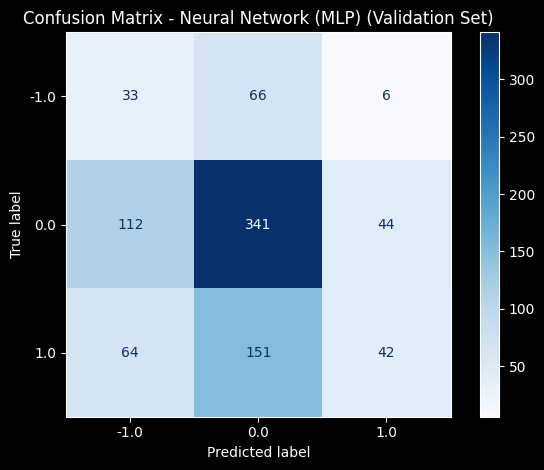

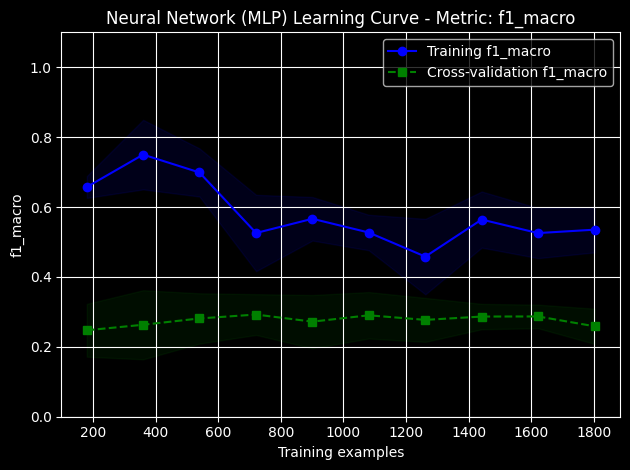

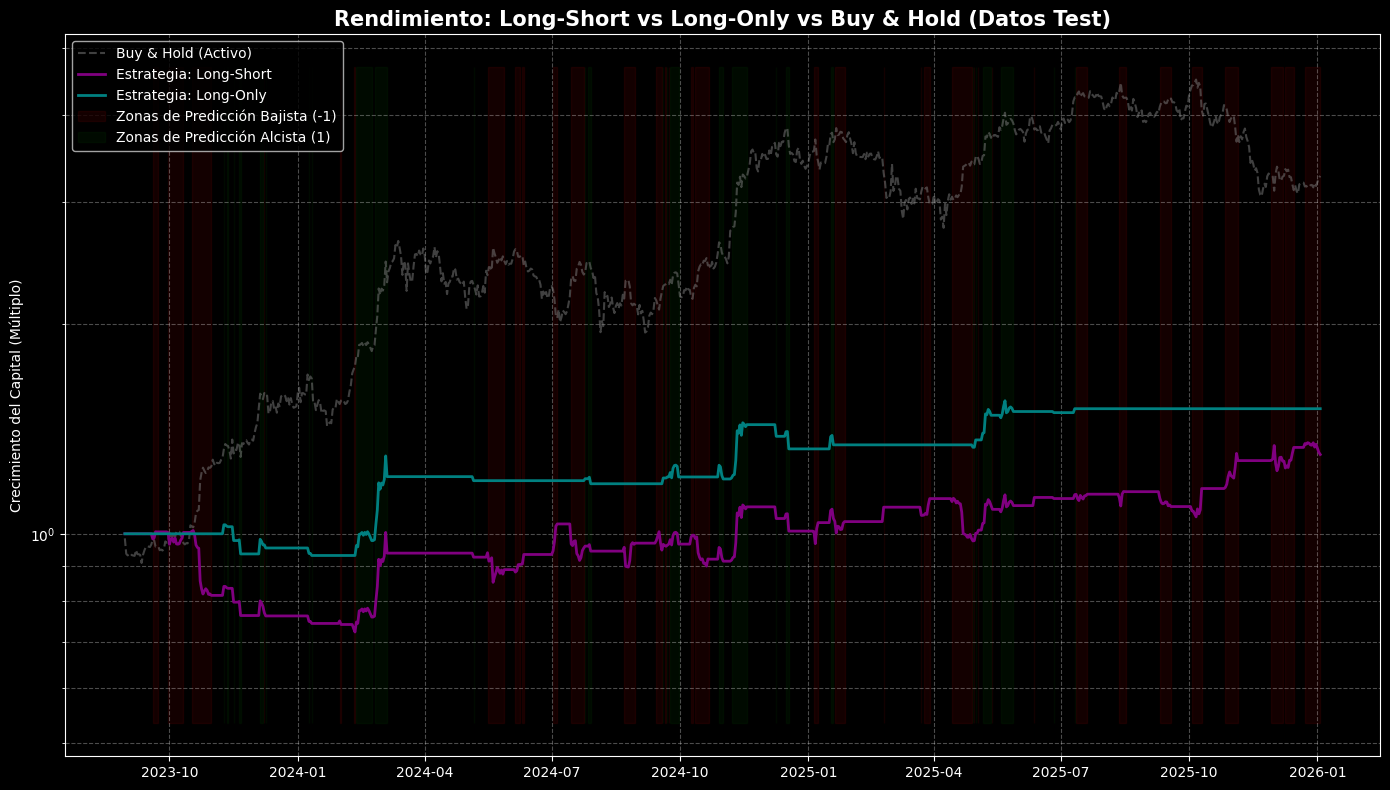


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.51x
Múltiplo final Long-Short:  1.30x


In [38]:
from sklearn.neural_network import MLPClassifier

METRIC = 'f1_macro'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

mlp_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    # max_iter alto para asegurar que la red converja (no se detenga antes de aprender)
    ("mlp", MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

# Grid de Hiperparámetros para la Red Neuronal
param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(10,), (20,), (10, 20, 10)], 
    # Función de activación (tanh suele ir muy bien en finanzas)
    "mlp__activation": ['relu', 'tanh'],
    # Regularización L2 (vital para evitar sobreajuste en datos ruidosos)
    "mlp__alpha": [0.0001, 0.01, 0.1],
    # Tasa de aprendizaje
    "mlp__learning_rate_init": [0.001, 0.01]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Red Neuronal MLP)...")
# Usamos y_train normal (-1, 0, 1), MLP lo soporta sin problemas
mlp_grid.fit(X_train, y_train)

print(f"\nBest CV {METRIC}: {mlp_grid.best_score_:.3f}")
print(f"Best params: {mlp_grid.best_params_}")

best_mlp = mlp_grid.best_estimator_

# Evaluación y gráficas usando y_test original
validation(estimator=best_mlp, X=X_test, y=y_test, estimator_name='Neural Network (MLP)')
plot_learning_curve(estimator=best_mlp, X=X_train, y=y_train, metric=METRIC, estimator_name='Neural Network (MLP)')

# Simulación financiera directa (sin wrappers, el MLP escupe -1, 0, 1)
plot_model_returns(best_mlp, X_test, df)
# plot_model_returns_variants(best_mlp, X_test, df) # Opcional


Iniciando optimización de hiperparámetros (Red Neuronal MLP)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best CV accuracy: 0.363
Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 80, 20), 'mlp__learning_rate_init': 0.01}
Validation Accuracy: 0.431

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.19      0.41      0.26       105
         0.0       0.64      0.46      0.54       497
         1.0       0.35      0.39      0.37       257

    accuracy                           0.43       859
   macro avg       0.40      0.42      0.39       859
weighted avg       0.50      0.43      0.45       859



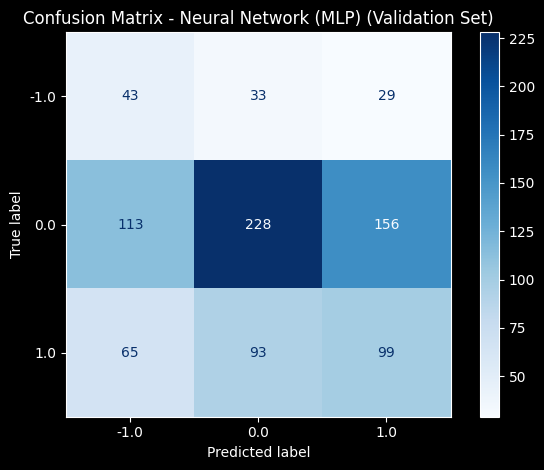

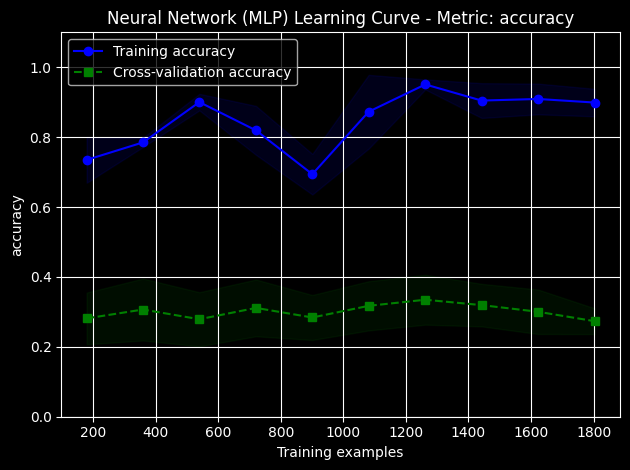

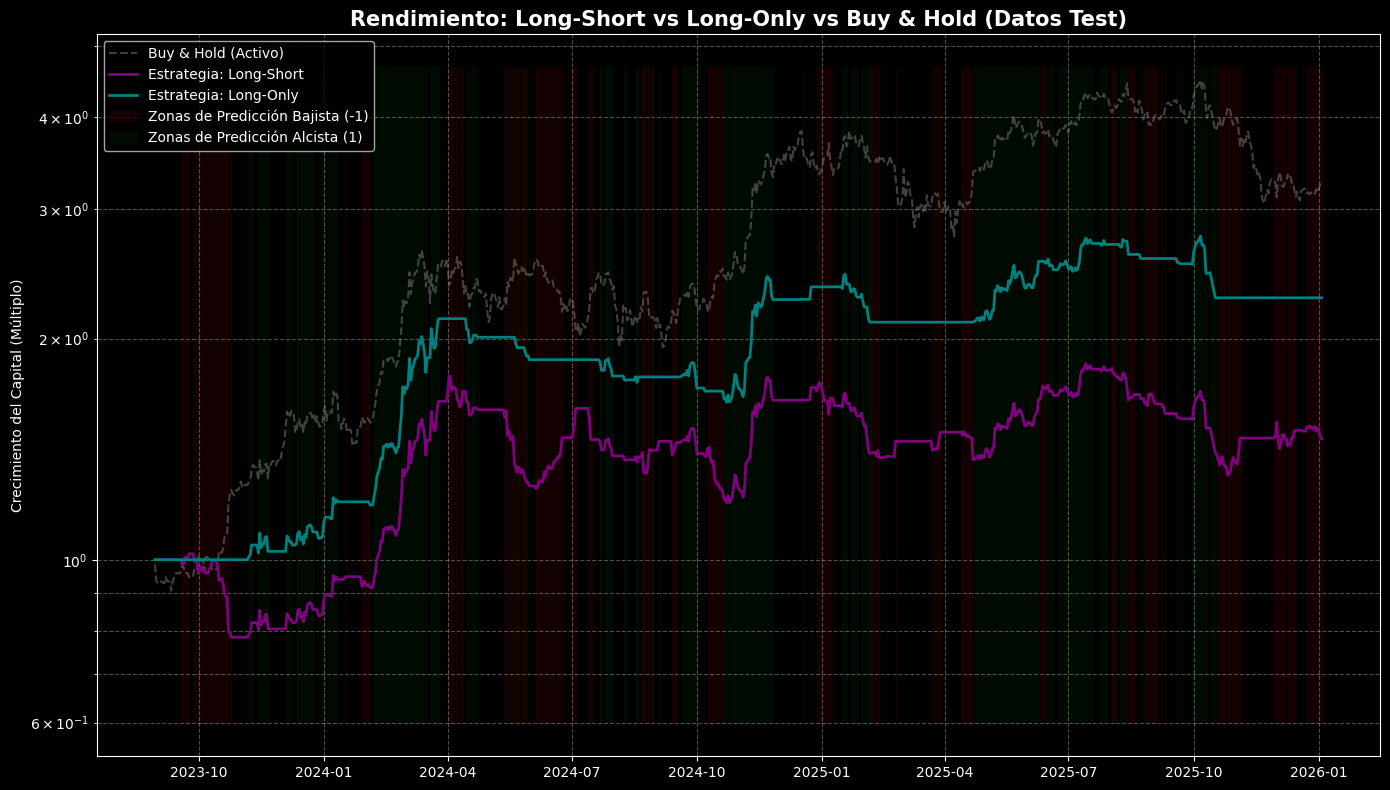


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   2.27x
Múltiplo final Long-Short:  1.46x


In [44]:
from sklearn.neural_network import MLPClassifier

METRIC = 'accuracy'

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

mlp_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor1),
    # max_iter alto para asegurar que la red converja (no se detenga antes de aprender)
    ("mlp", MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

# Grid de Hiperparámetros para la Red Neuronal
param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(50, 80, 20), (50, 80, 80, 40)], 
    # Función de activación (tanh suele ir muy bien en finanzas)
    "mlp__activation": ['tanh'],
    # Regularización L2 (vital para evitar sobreajuste en datos ruidosos)
    "mlp__alpha": [0.0001, 0.01],
    # Tasa de aprendizaje
    "mlp__learning_rate_init": [0.001, 0.01]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Red Neuronal MLP)...")
# Usamos y_train normal (-1, 0, 1), MLP lo soporta sin problemas
mlp_grid.fit(X_train, y_train)

print(f"\nBest CV {METRIC}: {mlp_grid.best_score_:.3f}")
print(f"Best params: {mlp_grid.best_params_}")

best_mlp = mlp_grid.best_estimator_

# Evaluación y gráficas usando y_test original
validation(estimator=best_mlp, X=X_test, y=y_test, estimator_name='Neural Network (MLP)')
plot_learning_curve(estimator=best_mlp, X=X_train, y=y_train, metric=METRIC, estimator_name='Neural Network (MLP)')
plot_model_returns(best_mlp, X_test, df)


Iniciando optimización de hiperparámetros (Red Neuronal MLP)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best CV accuracy: 0.349
Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (20, 40, 40, 10), 'mlp__learning_rate_init': 0.001}
Validation Accuracy: 0.315

Classification Report (Validation Set):

              precision    recall  f1-score   support

        -1.0       0.14      0.64      0.23       105
         0.0       0.67      0.27      0.38       497
         1.0       0.37      0.28      0.32       257

    accuracy                           0.32       859
   macro avg       0.39      0.39      0.31       859
weighted avg       0.52      0.32      0.34       859



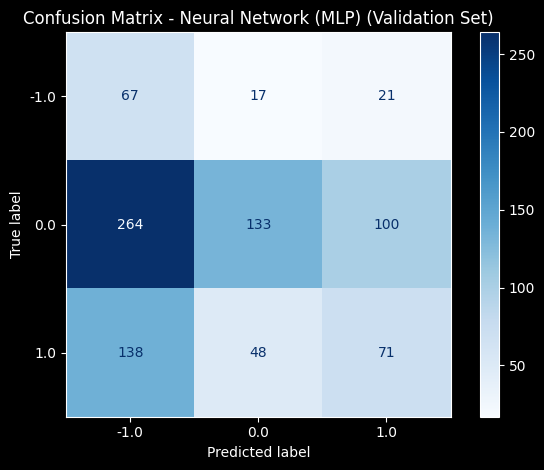

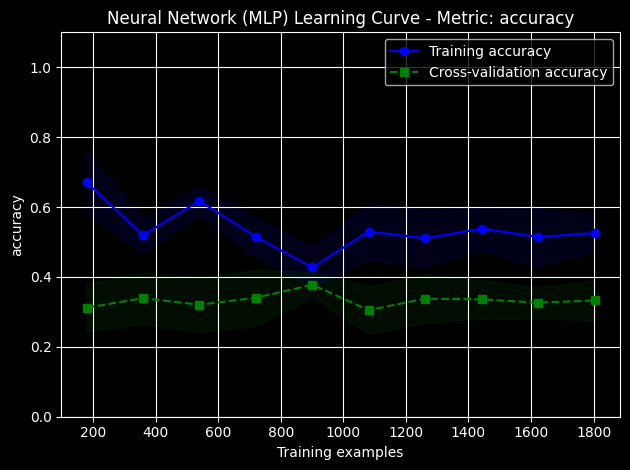

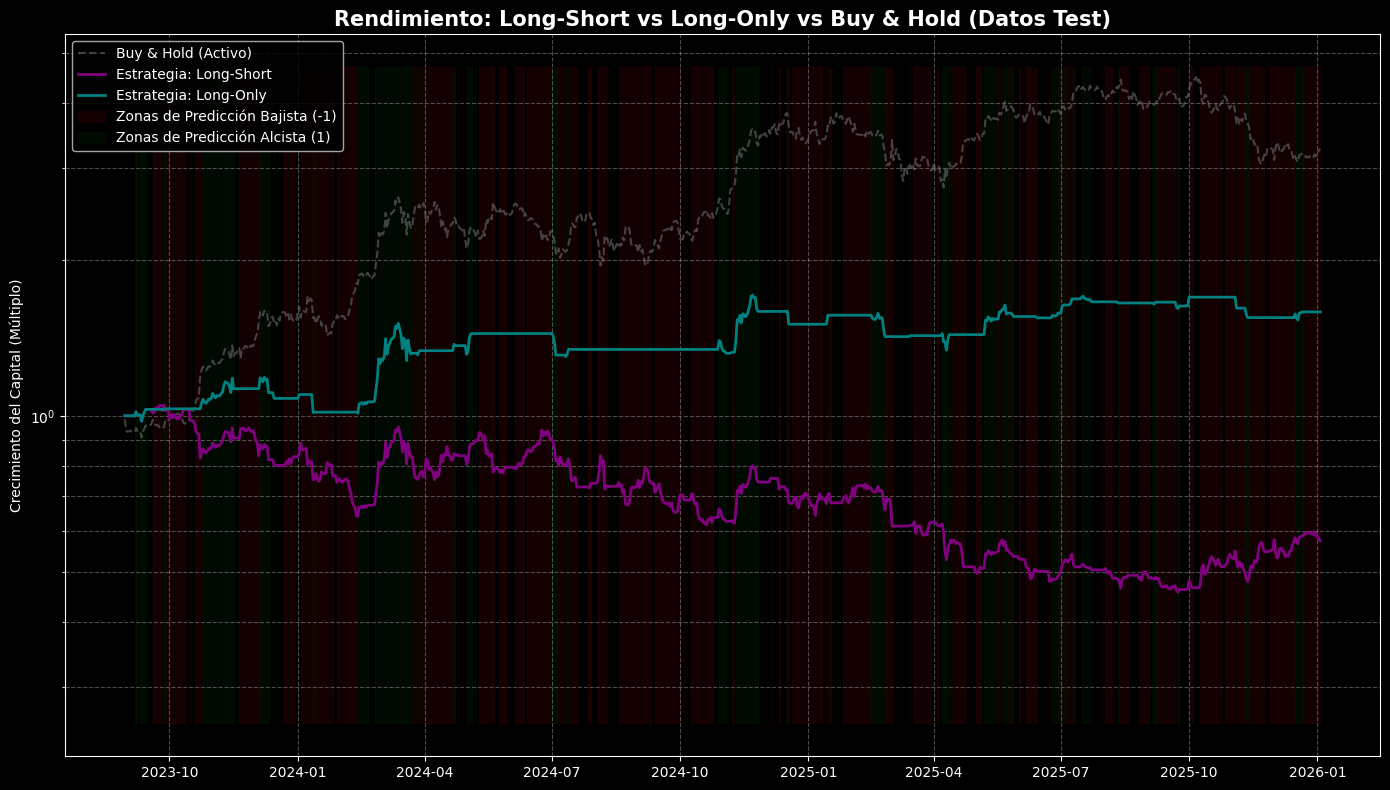


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   1.59x
Múltiplo final Long-Short:  0.57x


In [54]:
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

METRIC = 'accuracy'

numeric_transformer = ImbPipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)

mlp_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor1),
    ("undersampler", undersampler),
    ("mlp", MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

# Grid de Hiperparámetros para la Red Neuronal
param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(50, 80, 20), (20,), (20, 10), (20, 40, 40, 10)], 
    # Función de activación (tanh suele ir muy bien en finanzas)
    "mlp__activation": ['tanh'],
    # Regularización L2 (vital para evitar sobreajuste en datos ruidosos)
    "mlp__alpha": [0.0001, 0.01],
    # Tasa de aprendizaje
    "mlp__learning_rate_init": [0.001, 0.01]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (Red Neuronal MLP)...")
# Usamos y_train normal (-1, 0, 1), MLP lo soporta sin problemas
mlp_grid.fit(X_train, y_train)

print(f"\nBest CV {METRIC}: {mlp_grid.best_score_:.3f}")
print(f"Best params: {mlp_grid.best_params_}")

best_mlp = mlp_grid.best_estimator_

# Evaluación y gráficas usando y_test original
validation(estimator=best_mlp, X=X_test, y=y_test, estimator_name='Neural Network (MLP)')
plot_learning_curve(estimator=best_mlp, X=X_train, y=y_train, metric=METRIC, estimator_name='Neural Network (MLP)')
plot_model_returns(best_mlp, X_test, df)


Iniciando optimización de hiperparámetros (XGBoost)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV accuracy: 0.346
Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Validation Accuracy: 0.356

Classification Report (Validation Set):

              precision    recall  f1-score   support

         0.0       0.14      0.40      0.21       105
         1.0       0.60      0.36      0.45       497
         2.0       0.33      0.33      0.33       257

    accuracy                           0.36       859
   macro avg       0.36      0.36      0.33       859
weighted avg       0.46      0.36      0.38       859



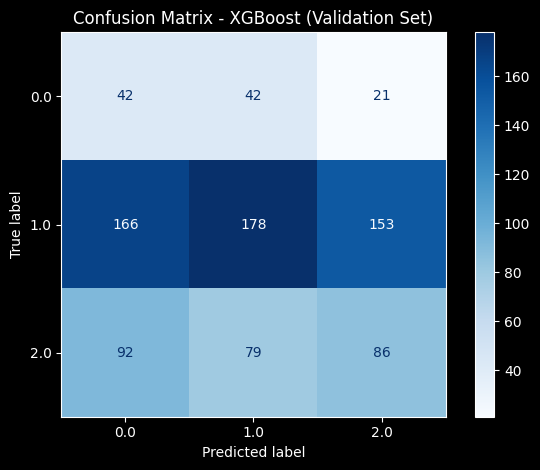

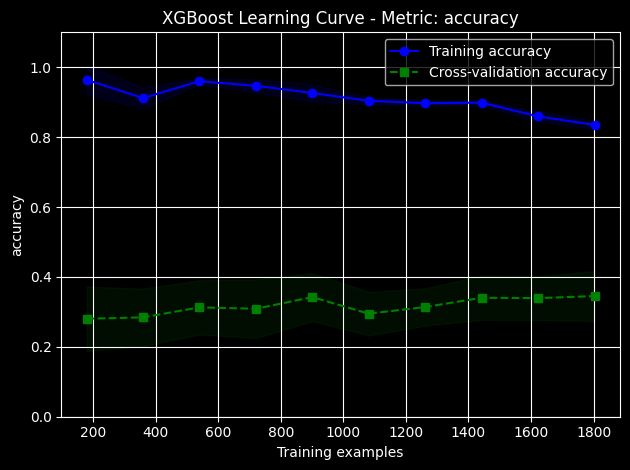

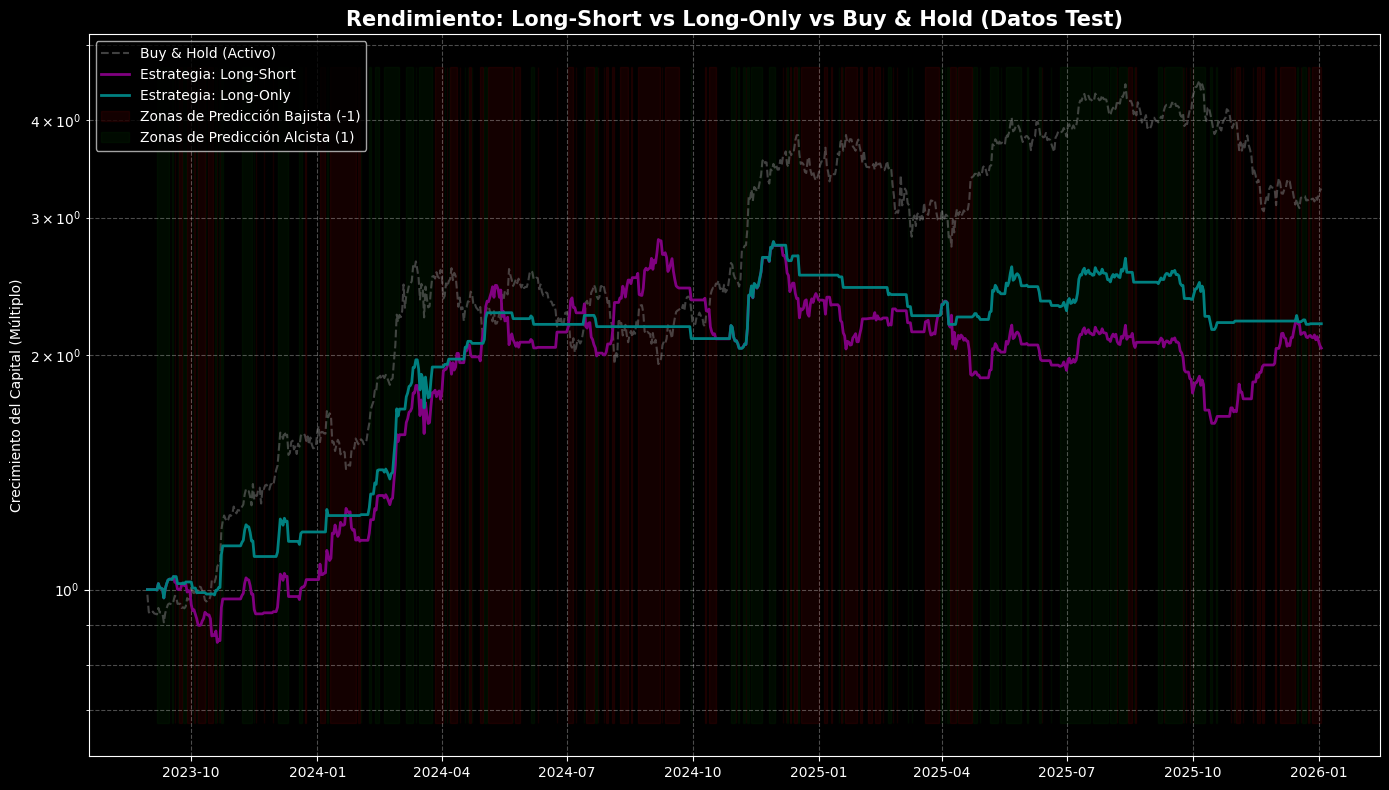


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   2.19x
Múltiplo final Long-Short:  2.04x


In [56]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

METRIC = 'accuracy'

y_train_xgb = y_train + 1
y_test_xgb = y_test + 1

undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)

numeric_transformer = ImbPipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

xgb_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor1),
    ("undersampler", undersampler),
    ("xgb", XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

y_train_xgb = y_train + 1

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (XGBoost)...")
xgb_grid.fit(X_train, y_train_xgb)

print(f"\nBest CV {METRIC}: {xgb_grid.best_score_:.3f}")
print(f"Best params: {xgb_grid.best_params_}")

best_xgb = xgb_grid.best_estimator_

validation(estimator=best_xgb, X=X_test, y=y_test_xgb, estimator_name='XGBoost')
plot_learning_curve(estimator=best_xgb, X=X_train, y=y_train_xgb, metric=METRIC, estimator_name='XGBoost')


class FinWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return self.model.predict(X) - 1

plot_model_returns(FinWrapper(best_xgb), X_test, df) 


Iniciando optimización de hiperparámetros (XGBoost)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV f1_macro: 0.332
Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Validation Accuracy: 0.356

Classification Report (Validation Set):

              precision    recall  f1-score   support

         0.0       0.14      0.40      0.21       105
         1.0       0.60      0.36      0.45       497
         2.0       0.33      0.33      0.33       257

    accuracy                           0.36       859
   macro avg       0.36      0.36      0.33       859
weighted avg       0.46      0.36      0.38       859



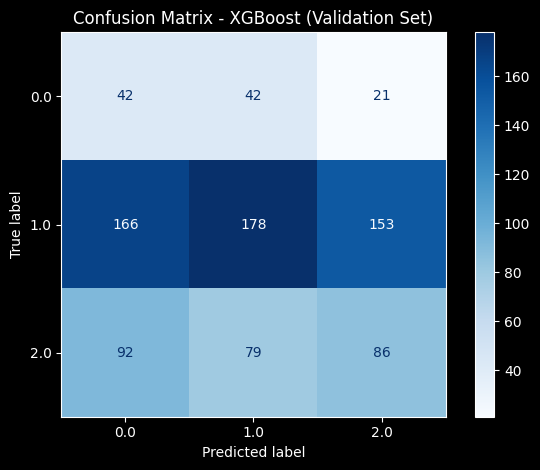

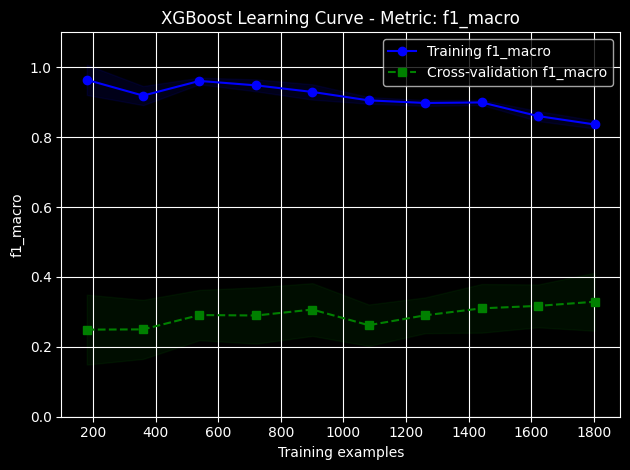

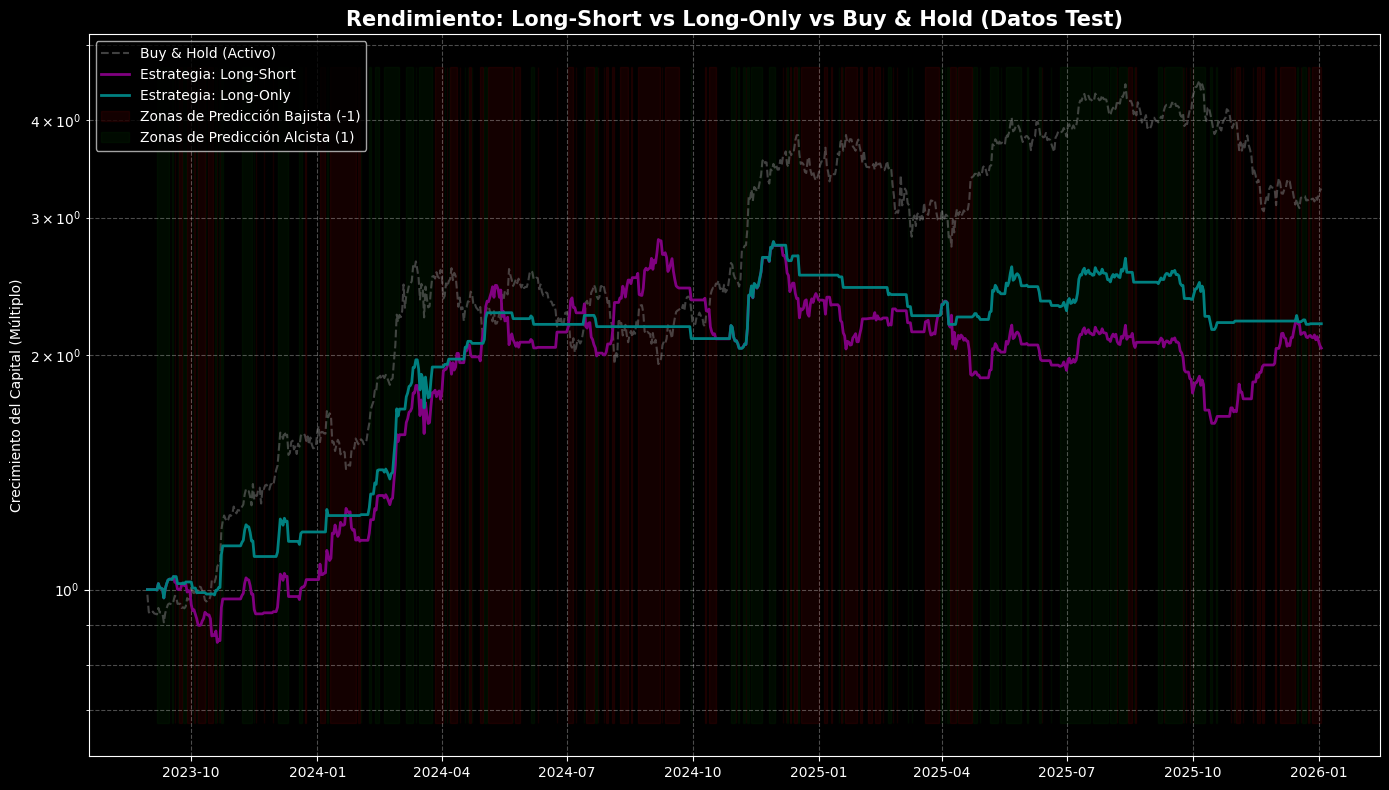


=== RESULTADOS DE LA SIMULACIÓN EN TEST ===
Múltiplo final Buy & Hold:  3.27x
Múltiplo final Long-Only:   2.19x
Múltiplo final Long-Short:  2.04x


In [55]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

METRIC = 'f1_macro'

y_train_xgb = y_train + 1
y_test_xgb = y_test + 1

undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)

numeric_transformer = ImbPipeline(steps=[
    ('scaler', StandardScaler()) 
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train.columns)
    ])

xgb_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor1),
    ("undersampler", undersampler),
    ("xgb", XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv_strategy = TimeSeriesSplit(n_splits=5)

y_train_xgb = y_train + 1

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=METRIC,
    verbose=1, 
    n_jobs=-1
)

print("\nIniciando optimización de hiperparámetros (XGBoost)...")
xgb_grid.fit(X_train, y_train_xgb)

print(f"\nBest CV {METRIC}: {xgb_grid.best_score_:.3f}")
print(f"Best params: {xgb_grid.best_params_}")

best_xgb = xgb_grid.best_estimator_

validation(estimator=best_xgb, X=X_test, y=y_test_xgb, estimator_name='XGBoost')
plot_learning_curve(estimator=best_xgb, X=X_train, y=y_train_xgb, metric=METRIC, estimator_name='XGBoost')


class FinWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return self.model.predict(X) - 1

plot_model_returns(FinWrapper(best_xgb), X_test, df) 